# Harvard's Endowment — Group Case

**FINM Portfolio and Risk Management**

Case link: [Harvard's Endowment](https://markhendricks.github.io/finm-portfolio/case_studies/Harvard%27s%20Endowment.html)

| Section | Author |
|---|---|
| 2.1 Summary Statistics, 2.2 Descriptive Analysis | *(name)* |
| 2.3 The MV Frontier, 2.4 TIPS | *(name)* |
| 3. Allocations | *(name)* |

# 2. Mean-Variance Optimization

## Setup

* **Data:** `data/multi_asset_etf_data.xlsx`, monthly returns of 11 asset-class ETFs plus SHV (short-term T-bill fund).
* **Excess returns:** SHV is the risk-free asset, so every other column is in excess of SHV. We load the `excess returns` sheet and check it against `total returns` − SHV.
* **Adjustment:** QAI is dropped, which leaves **10 assets**.
* **Nominal** returns, with no inflation adjustment.
* **Format:** statistics are annualized (mean × 12, volatility × $\sqrt{12}$, Sharpe × $\sqrt{12}$). The raw time series is never scaled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams['figure.figsize'] = (10, 5)

FREQ = 12                                   # monthly data
DATA_PATH = 'data/multi_asset_etf_data.xlsx'

In [2]:
info       = pd.read_excel(DATA_PATH, sheet_name='descriptions').set_index('ticker')
total_rets = pd.read_excel(DATA_PATH, sheet_name='total returns', index_col=0, parse_dates=True)
rets       = pd.read_excel(DATA_PATH, sheet_name='excess returns', index_col=0, parse_dates=True)

# Sanity check: provided excess returns == total returns minus SHV
recomputed = total_rets.drop(columns='SHV').sub(total_rets['SHV'], axis=0)
assert np.allclose(recomputed[rets.columns], rets), 'excess returns sheet inconsistent'

# Adjustment: drop QAI and analyze the remaining 10 assets
rets = rets.drop(columns='QAI')

print(f'Sample: {rets.index[0]:%Y-%m} to {rets.index[-1]:%Y-%m}  ({len(rets)} monthly obs, {rets.shape[1]} assets)')
info.loc[rets.columns, ['shortName']]

Sample: 2011-02 to 2026-07  (186 monthly obs, 10 assets)


,shortName
BWX,State Street SPDR Bloomberg Int
DBC,Invesco DB Commodity Index Trac
EEM,iShares MSCI Emerging Index Fun
EFA,iShares MSCI EAFE ETF
HYG,iShares iBoxx $ High Yield Corp
IEF,iShares 7-10 Year Treasury Bond
IYR,iShares U.S. Real Estate ETF
PSP,Invesco Global Listed Private E
SPY,State Street SPDR S&P 500 ETF T
TIP,iShares TIPS Bond ETF


In [3]:
def performance_summary(df, freq=FREQ):
    # Annualized mean, volatility, and Sharpe ratio of (excess) return series
    out = pd.DataFrame({
        'Mean':       df.mean() * freq,
        'Volatility': df.std() * np.sqrt(freq),
    })
    out['Sharpe'] = out['Mean'] / out['Volatility']
    return out

## 2.1 Summary Statistics

> Calculate and display the mean and volatility of each asset's excess return. Which assets have the best and worst Sharpe ratios?

$$\text{Sharpe ratio}_i = \frac{\tilde{\mu}_i}{\sigma_i}$$

where $\tilde{\mu}_i$ is the mean excess return. All three statistics are annualized.

In [4]:
summary = performance_summary(rets).sort_values('Sharpe', ascending=False)
summary.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}'}) \
       .background_gradient(subset=['Sharpe'], cmap='RdYlGn')

,Mean,Volatility,Sharpe
SPY,12.70%,14.14%,0.898
HYG,3.45%,7.33%,0.471
EFA,6.38%,14.86%,0.429
IYR,7.01%,16.55%,0.423
PSP,7.64%,21.13%,0.362
TIP,1.28%,4.97%,0.257
EEM,4.44%,17.91%,0.248
IEF,0.86%,6.21%,0.138
DBC,1.30%,17.23%,0.075
BWX,-1.72%,8.19%,-0.210


Best Sharpe : SPY (State Street SPDR S&P 500 ETF T)  -> 0.898
Worst Sharpe: BWX (State Street SPDR Bloomberg Int)  -> -0.210


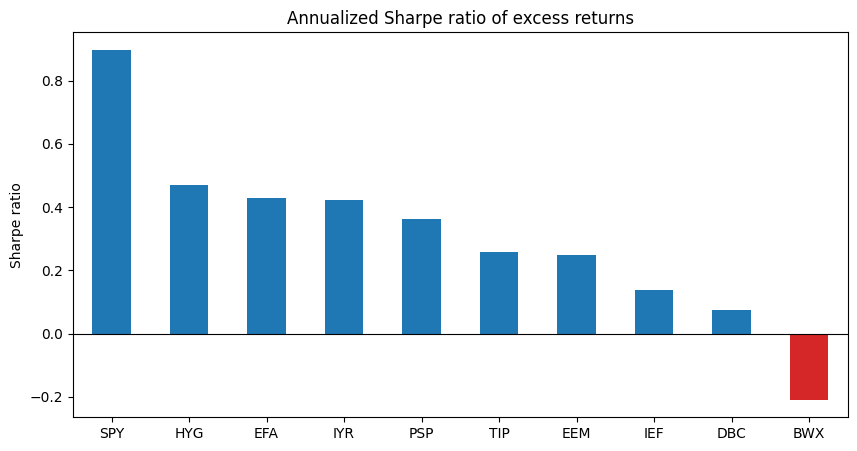

In [5]:
best, worst = summary['Sharpe'].idxmax(), summary['Sharpe'].idxmin()
print(f"Best Sharpe : {best} ({info.loc[best, 'shortName'].strip()})  -> {summary.loc[best, 'Sharpe']:.3f}")
print(f"Worst Sharpe: {worst} ({info.loc[worst, 'shortName'].strip()})  -> {summary.loc[worst, 'Sharpe']:.3f}")

fig, ax = plt.subplots()
summary['Sharpe'].plot.bar(ax=ax, color=np.where(summary['Sharpe'] >= 0, 'tab:blue', 'tab:red'))
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Annualized Sharpe ratio of excess returns')
ax.set_ylabel('Sharpe ratio')
plt.xticks(rotation=0)
plt.show()

**Takeaways (2.1)**

* **Best Sharpe: SPY (U.S. equities), ≈ 0.90.** SPY has the highest mean excess return (≈ 12.7% annualized) with a volatility of only ≈ 14%, which is lower than other equity-like assets such as EEM, IYR, and PSP. Over this sample U.S. equities earned far more per unit of risk than anything else.
* **Worst Sharpe: BWX (foreign government bonds), ≈ −0.21.** It is the only asset with a *negative* mean excess return (≈ −1.7%), so it underperformed T-bills over the sample. Unhedged currency exposure during a period of a strong U.S. dollar explains much of this.
* DBC (commodities) also has a very low Sharpe (≈ 0.08): commodity volatility is equity-like (≈ 17%) but the excess return is close to zero.
* High-yield credit (HYG) ranks second (≈ 0.47) because its volatility is low relative to its mean.
* These are sample estimates. With about 15 years of monthly data, the standard error of an annualized Sharpe ratio is roughly $1/\sqrt{15.5} \approx 0.25$, so the differences between assets in the middle of the ranking are not statistically meaningful.

## 2.2 Descriptive Analysis

> Calculate the correlation matrix of the returns. Which pair has the highest correlation? And the lowest?

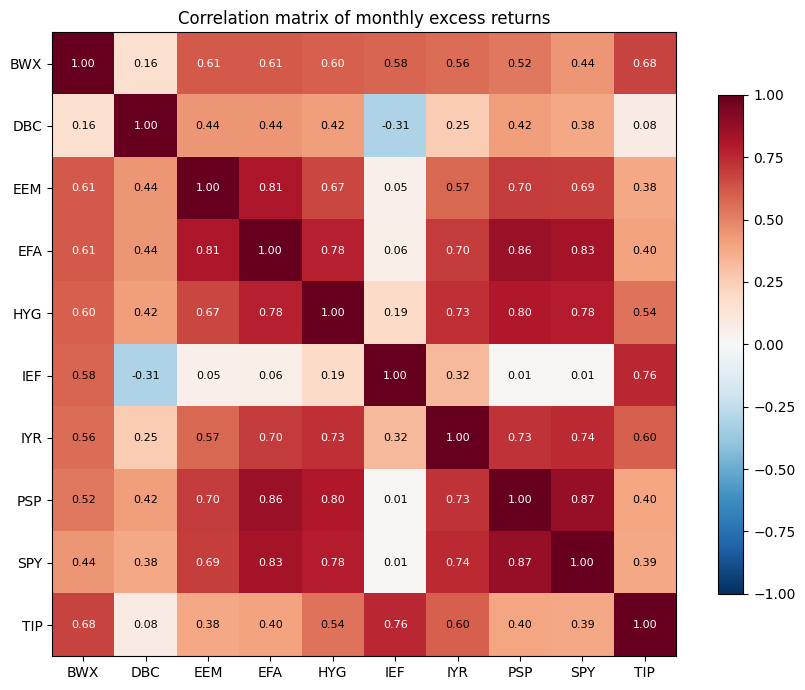

In [6]:
corr = rets.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation matrix of monthly excess returns')
plt.tight_layout()
plt.show()

In [7]:
# Unique pairs (upper triangle, excluding the diagonal)
mask  = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(mask).stack().rename('Correlation').sort_values(ascending=False)
pairs.index.names = ['Asset 1', 'Asset 2']

print('Highest correlation pair:', pairs.index[0],  f'-> {pairs.iloc[0]:.3f}')
print('Lowest  correlation pair:', pairs.index[-1], f'-> {pairs.iloc[-1]:.3f}')

pd.concat({'Top 5': pairs.head(5).reset_index(), 'Bottom 5': pairs.tail(5).reset_index()}, axis=1)

Highest correlation pair: ('PSP', 'SPY') -> 0.872
Lowest  correlation pair: ('DBC', 'IEF') -> -0.309


Top 5                     Bottom 5                    
  Asset 1 Asset 2 Correlation  Asset 1 Asset 2 Correlation
0     PSP     SPY      0.8722      EFA     IEF      0.0629
1     EFA     PSP      0.8616      EEM     IEF      0.0515
2     EFA     SPY      0.8328      IEF     PSP      0.0125
3     EEM     EFA      0.8120      IEF     SPY      0.0113
4     HYG     PSP      0.7983      DBC     IEF     -0.3088

**Takeaways (correlations)**

* **Highest: PSP & SPY (≈ 0.87).** Listed private equity is mostly a portfolio of publicly traded equities, so it moves closely with the U.S. stock market. EFA–PSP (≈ 0.86) and EFA–SPY (≈ 0.83) come next. The equity-like assets (SPY, EFA, EEM, PSP, IYR, HYG) form one highly correlated block, which means they diversify each other less than it looks.
* **Lowest: DBC & IEF (≈ −0.31).** Commodities and intermediate Treasuries move in opposite directions. Inflation and growth surprises push commodity prices up and Treasury prices down, and in risk-off episodes Treasuries rally while commodities sell off.
* IEF is roughly uncorrelated with the equity block (≈ 0.01 with SPY and PSP), which makes Treasuries the main diversifier in this asset set.

> How well have TIPS done in our sample? Have they outperformed domestic bonds? Foreign bonds?

Domestic bonds = **IEF** (7–10y U.S. Treasuries); foreign bonds = **BWX** (international Treasuries).

In [8]:
bonds = ['TIP', 'IEF', 'BWX']

tips_cmp = performance_summary(rets[bonds])
tips_cmp['Cumulative total return'] = (1 + total_rets[bonds]).prod() - 1
tips_cmp['Max drawdown'] = ((1 + total_rets[bonds]).cumprod()
                            .pipe(lambda w: w / w.cummax() - 1).min())
tips_cmp['Corr w/ TIP'] = corr.loc[bonds, 'TIP']

tips_cmp.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}',
                       'Cumulative total return': '{:.1%}', 'Max drawdown': '{:.1%}',
                       'Corr w/ TIP': '{:.2f}'})

,Mean,Volatility,Sharpe,Cumulative total return,Max drawdown,Corr w/ TIP
TIP,1.28%,4.97%,0.257,50.3%,-13.9%,1.00
IEF,0.86%,6.21%,0.138,39.4%,-23.2%,0.76
BWX,-1.72%,8.19%,-0.210,-8.5%,-32.2%,0.68


,Mean,Volatility,Info ratio,t-stat (mean),% months TIP better
TIP - IEF,0.42%,4.08%,0.103,0.40,53.8%
TIP - BWX,2.99%,6.07%,0.493,1.94,56.5%


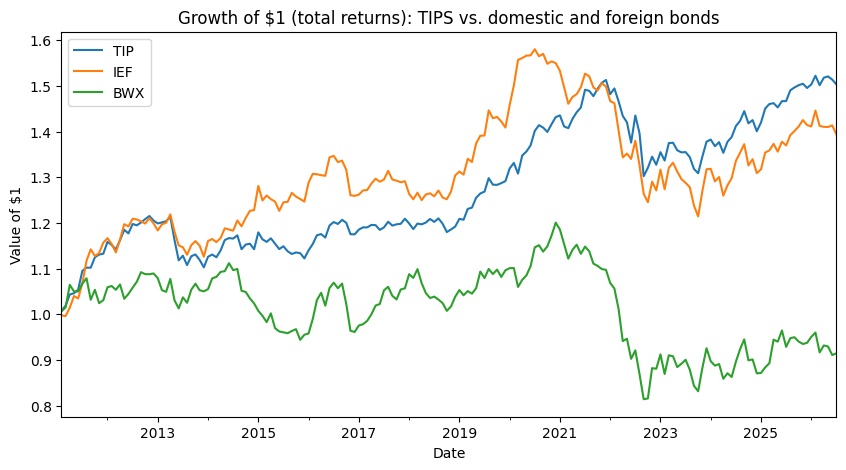

In [9]:
# Outperformance of TIPS: monthly excess-return differences (annualized)
diff = pd.DataFrame({f'TIP - {b}': rets['TIP'] - rets[b] for b in ['IEF', 'BWX']})
diff_stats = performance_summary(diff).rename(columns={'Sharpe': 'Info ratio'})
diff_stats['t-stat (mean)'] = diff.mean() / (diff.std() / np.sqrt(len(diff)))
diff_stats['% months TIP better'] = (diff > 0).mean()
display(diff_stats.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Info ratio': '{:.3f}',
                                 't-stat (mean)': '{:.2f}', '% months TIP better': '{:.1%}'}))

fig, ax = plt.subplots()
(1 + total_rets[bonds]).cumprod().plot(ax=ax)
ax.set_title('Growth of $1 (total returns): TIPS vs. domestic and foreign bonds')
ax.set_ylabel('Value of $1')
plt.show()

**Takeaways (TIPS)**

* **TIPS vs. domestic bonds (IEF):** TIPS earned a slightly higher mean excess return (≈ 1.3% vs. ≈ 0.9%) with *lower* volatility (≈ 5.0% vs. ≈ 6.2%), so the Sharpe ratio is higher (≈ 0.26 vs. ≈ 0.14), and cumulative total return is also higher. TIPS outperformed IEF on a risk-adjusted basis. The margin is small, though, and not statistically significant: the mean of TIP − IEF is only ≈ 0.4% per year (t ≈ 0.4), and TIPS beat IEF in just ≈ 54% of months. Most of the edge comes from the 2021–22 inflation surge, when TIPS outperformed nominal Treasuries by ≈ 9% and ≈ 3%. In most other years they performed about the same or trailed.
* **TIPS vs. foreign bonds (BWX):** TIPS clearly outperformed, by ≈ 3.0% per year (t ≈ 1.9, borderline significant). BWX had a negative excess return, higher volatility, and lost money over the sample in total-return terms.
* **Do TIPS diversify?** TIPS are highly correlated with IEF (≈ 0.76) and BWX (≈ 0.68), so most of their variation is ordinary interest-rate risk. Their correlation with equities is moderate (≈ 0.4). Whether they add value as a separate asset class therefore depends on the part of TIPS returns that is *not* spanned by the other assets. Section 2.4 tests this with the MV frontier.

---
## 2.3 The MV Frontier

*(to be completed — use `rets`, `performance_summary`, `FREQ` from the Setup section)*